# HNL sensitivity from the forward neutrino flux

Feasibility estimate of a **forward neutrino detector at 5 km** and its reach to a
**heavy neutral lepton (HNL)** $N$ that mixes with the active neutrinos, $|U_{aN}|^2$,
for masses **above the $D$ meson** ($m_N \sim 2$–$6$ GeV). The signal chain, kept
deliberately simple (see `mint/hnl_tools.py`):

1. **Upscattering** $\nu\,\mathcal{N}\to N\,X$ — neutral-current DIS with a mixing
   insertion, $\sigma \simeq |U|^2\,\sigma_{\rm NC}^{\rm SM}(E_\nu)$.
2. **Propagation** — the boosted $N$ ($\gamma_N = E_N/m_N \sim 10^3$) travels through
   the detector.
3. **Decay** $N\to$ visible ($\nu\ell^+\ell^-$, $\ell^\pm+$hadrons, …) inside the volume.

The rate scales as $|U|^2$ (production) $\times$ decay probability, giving the familiar
$|U|^2$ (short-lived) to $|U|^4$ (long-lived) behaviour of the reach. This is a
first pass: the cross section, HNL width, inelasticity and visible branching are all
leading-order/approximate and exposed as parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mint import lattice_tools as lt, beam_optics as bopt, const
from mint import detector_tools as dt
from mint import hnl_tools as hnl
from mint.MuC import MuDecaySimulator

import vector
np.random.seed(1)


## 1. Forward neutrino flux at 5 km (from the beam simulation)

In [2]:
# Build the 10 TeV-class IR ring and simulate the forward mu+ -> nu_mu-bar flux.
twiss_file = "beam-optics/twiss_ir1ccma_hybrid_v06.outx"
ring_df = lt.get_lattice_dataframe_from_tfs(twiss_file)
ring_dict = bopt.create_smoothed_lattice(
    ring_df, emittance_RMS=25e-6/(5e3/0.105), n_elements=120000,
    rotated=True, if_sublattice=False, midpoint=True,
)
ring = lt.Lattice(**ring_dict)
ring.Nmu_per_bunch = 2e12
ring.finj = 5.0
ring.bunch_multiplicity = 1.0
ring.duty_factor = 1 / np.pi
print(f"Ring circumference: {ring.s(1)/1e5:.2f} km")

nuflavor = "numubar"
sim = MuDecaySimulator(muon_polarization=0.0, lattice=ring, nuflavor=nuflavor,
                       n_evals=3e5, beam_dynamics=True)
sim.decay_muons()
sim.place_muons_on_lattice(lattice=ring, direction="clockwise")

bunches_per_year = ring.finj * ring.bunch_multiplicity * ring.duty_factor * const.s_in_year
print(f"Bunches/year: {bunches_per_year:.2e}")


Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7ac0>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7b10>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7bb0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7c00>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7c50>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7ca0>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7cf0>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7d40>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7d90>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x17a7b7de0>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

neutrinos through the 1 m-radius face at 5 km: 5.661e+14 / year  (33687 MC events)


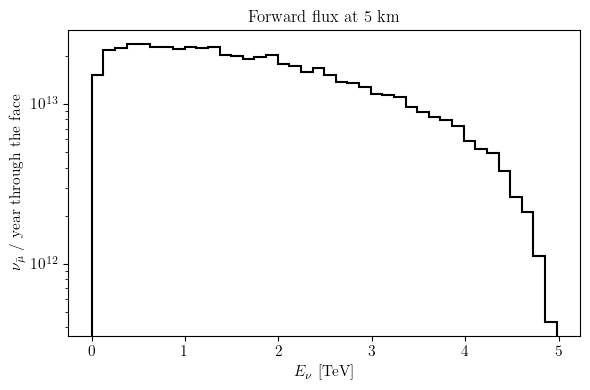

In [3]:
# Select neutrinos crossing the detector face at z = 5 km and get their annual flux.
DIST = 5e5      # cm (5 km)
DET_R = 100.0   # cm (1 m radius)

det_vec = vector.array({"x": [0.0], "y": [0.0], "z": [DIST]})
distances = det_vec - sim.pos
ndir = sim.pnu.to_3D().unit()
dotprod = distances.dot(ndir)
lam = (DIST - sim.pos["z"]) / sim.pnu["pz"]
x_hit = sim.pos["x"] + lam * sim.pnu["px"]
y_hit = sim.pos["y"] + lam * sim.pnu["py"]
hit = (dotprod > 0) & (sim.pnu["E"] > 0) & (np.sqrt(x_hit**2 + y_hit**2) < DET_R)

E_nu = sim.pnu["E"][hit]
w_nu = sim.weights.flatten()[hit] * bunches_per_year   # neutrinos through the face / year
print(f"neutrinos through the 1 m-radius face at 5 km: {w_nu.sum():.3e} / year  ({hit.sum()} MC events)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(E_nu/1e3, bins=40, weights=w_nu, histtype="step", color="black", lw=1.5)
ax.set_xlabel(r"$E_\nu$ [TeV]"); ax.set_ylabel(r"$\nu_{\bar\mu}$ / year through the face")
ax.set_yscale("log"); ax.set_title("Forward flux at 5 km")
plt.tight_layout()


## 2. HNL ingredients: upscattering cross section and decay length

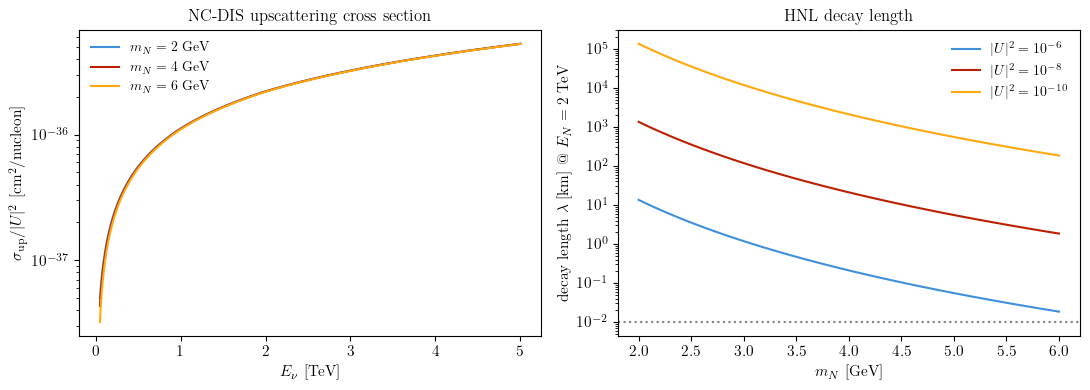

In [4]:
Egrid = np.geomspace(50, 5e3, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# upscattering cross section (per nucleon), shown at |U|^2 = 1 to factor it out
for mN in [2.0, 4.0, 6.0]:
    ax[0].plot(Egrid/1e3, hnl.mixing_upscattering_xsec(Egrid, mN, 1.0, nuflavor),
               label=fr"$m_N={mN:.0f}$ GeV")
ax[0].set_xlabel(r"$E_\nu$ [TeV]")
ax[0].set_ylabel(r"$\sigma_{\rm up}/|U|^2$  [cm$^2$/nucleon]")
ax[0].set_yscale("log"); ax[0].legend(frameon=False)
ax[0].set_title("NC-DIS upscattering cross section")

# HNL lab decay length vs mass, at E_N = 2 TeV
E_N = 2000.0
mgrid = np.linspace(2.0, 6.0, 100)
for U2 in [1e-6, 1e-8, 1e-10]:
    lam = hnl.decay_length(E_N, mgrid, hnl.mixing_total_width(mgrid, U2))
    ax[1].plot(mgrid, lam/1e5, label=fr"$|U|^2=10^{{{int(np.log10(U2))}}}$")
ax[1].axhline(0.01, ls=":", color="gray")  # 10 m detector in km
ax[1].set_xlabel(r"$m_N$ [GeV]"); ax[1].set_ylabel(r"decay length $\lambda$ [km] @ $E_N=2$ TeV")
ax[1].set_yscale("log"); ax[1].legend(frameon=False)
ax[1].set_title("HNL decay length")
plt.tight_layout()


## 3. Signal scan over $(m_N,\ |U|^2)$

detector: 10 m iron, nucleon density 4.75e+24 /cm^3


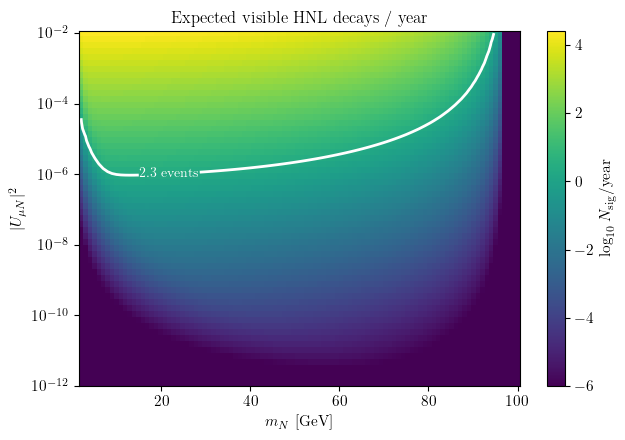

In [9]:
detector = hnl.ForwardDetector(distance_cm=DIST, radius_cm=DET_R,
                               length_cm=1000.0, material=dt.Fe)  # 10 m iron block
print(f"detector: 10 m iron, nucleon density {detector.nucleon_density:.2e} /cm^3")

m_N_grid = np.linspace(2.0, 100.0, 100)
U2_grid = np.geomspace(1e-12, 1e-2, 60)
mixing = lambda m: hnl.MixingPortal(m, nuflavor=nuflavor, y_mean=0.3, br_vis=0.5, n_eff=10.0)
N_sig = hnl.sensitivity_grid(E_nu, w_nu, m_N_grid, U2_grid, detector, portal_factory=mixing)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
pc = ax.pcolormesh(m_N_grid, U2_grid, np.log10(np.clip(N_sig.T, 1e-6, None)),
                   shading="auto", cmap="viridis")
cs = ax.contour(m_N_grid, U2_grid, N_sig.T, levels=[2.3], colors="white", linewidths=2)
ax.clabel(cs, fmt="2.3 events")
ax.set_yscale("log"); ax.set_xlabel(r"$m_N$ [GeV]"); ax.set_ylabel(r"$|U_{\mu N}|^2$")
fig.colorbar(pc, label=r"$\log_{10} N_{\rm sig}$/year")
ax.set_title("Expected visible HNL decays / year")
plt.tight_layout()


## 4. Sensitivity reach (90% CL, background-free)

best reach: |U|^2 ~ 1.26e-06 at m_N = 7.94 GeV


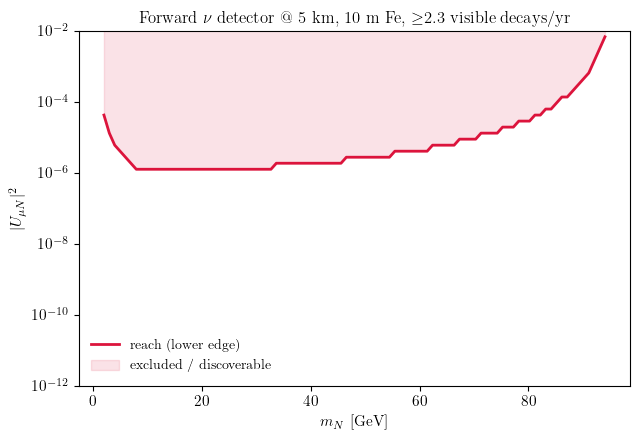

In [10]:
lower, upper = hnl.exclusion_band(m_N_grid, U2_grid, N_sig, n_events=2.3)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(m_N_grid, lower, color="crimson", lw=2, label="reach (lower edge)")
ax.fill_between(m_N_grid, lower, 1e-2, color="crimson", alpha=0.12, label="excluded / discoverable")
ax.set_yscale("log"); ax.set_ylim(1e-12, 1e-2)
ax.set_xlabel(r"$m_N$ [GeV]"); ax.set_ylabel(r"$|U_{\mu N}|^2$")
ax.set_title(r"Forward $\nu$ detector @ 5 km, 10 m Fe, $\geq$2.3 visible decays/yr")
ax.legend(frameon=False)
plt.tight_layout()

i_best = np.nanargmin(lower)
print(f"best reach: |U|^2 ~ {np.nanmin(lower):.2e} at m_N = {m_N_grid[i_best]:.2f} GeV")


## 5. Critical notes and next steps

**What this captures.** The correct scaling structure — signal $\propto |U|^4$ in the
long-lived regime (decay length $\gg$ detector) turning to $\propto |U|^2$ when the HNL
decays inside the block — and realistic inputs: the *simulated* forward flux (energy
spectrum and normalisation) at 5 km, the data-driven SM NC-DIS cross section, and the
HNL boost $\gamma_N = E_N/m_N$ that sets the decay length.

**Simplifications to revisit.**
- **HNL width** uses an effective channel count `n_eff` ($\propto m_N^5$); replace with
  channel-resolved partial widths (Bondarenko et al. 2018) for the correct $m_N$
  dependence and $|U|^2$-per-flavour structure.
- **Upscattering** is $|U|^2\,\sigma_{\rm NC}^{\rm SM}$ with a crude threshold; a proper
  treatment needs the HNL-mass-dependent DIS kinematics (modified $x,y$ limits) and the
  outgoing-$N$ energy distribution instead of a single $\langle y\rangle$.
- **Geometry** is a single homogeneous block (production + decay in the same volume), so
  the reach has a **lower edge only**. A realistic setup — an upstream absorber/target
  where $N$ is produced, a gap, then a low-density fiducial decay volume — adds an
  **upper edge** ($N$ decaying before it reaches the detector) and closes the band. That
  is a small extension: multiply by $e^{-d_{\rm gap}/\lambda}$ and use a separate
  fiducial length.
- **Backgrounds** are assumed zero (2.3 events = 90% CL). Real backgrounds (SM $\nu$ NC
  events faking a decay, cosmic, beam-induced) must be estimated; the enormous forward
  flux is both the signal source and the main background.
- **Flavour/beam:** only $\bar\nu_\mu$ from the $\mu^+$ beam is used; adding $\nu_\mu$
  from the $\mu^-$ beam and the $\nu_e/\bar\nu_e$ components increases the rate and lets
  you probe $|U_{eN}|^2$ as well.

**Why a muon collider is interesting here.** The forward flux is intense and reaches
multi-TeV, so the HNL boost is huge ($\lambda \propto E_N$) — long decay lengths bring
even weakly-mixed, GeV-scale HNLs into a km-scale detector, a regime complementary to
beam-dump and fixed-target searches.